# tsib energy system demo

`tsib.optimization` builds [oemof-solph](https://oemof-solph.readthedocs.io/) energy systems out of
parameterized buildings. tsib contributes exactly two things:

1. **the 5R1C thermal zone** — the one piece of building physics solph has no equivalent for;
2. **a building block kit** — specs, presets and factories that turn a building configuration into
   a ready-to-solve system.

The idea that drives everything: **the thermal zone is a component, not a precomputed load
profile.** Its temperature states are free decision variables inside a comfort band, so the
building's thermal mass is a dispatchable storage in the *same* optimization as the battery, the
heat pump and the electricity price.

This notebook shows:

1. [the heat load](#1) — the production path, a zone supplied by priced heat
2. [thermal mass as flexibility](#2) — the same building against a price spike
3. [the building block kit](#3) — specs, presets, and adding a component
4. [a whole building](#4) — heat pump + PV + battery + buffer, sized by the optimizer

In [1]:
import json
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import tsib
from tsib.optimization import (
    SystemSpec, build_system, node_results, objective_value, presets, solve,
)

warnings.filterwarnings("ignore", category=UserWarning)
plt.rcParams.update({"figure.figsize": (11, 3.2), "axes.grid": True,
                     "grid.alpha": 0.3, "axes.spines.top": False,
                     "axes.spines.right": False})

<a id="1"></a>
## 1. The heat load

A TABULA archetype single-family house in DWD test reference year zone 4. `refurbishment=False`
keeps the envelope fixed, so no binaries are created and the model stays a pure LP;
`capControl=True` installs a smart thermostat, which is what opens the comfort band and makes the
building flexible at all.

In [2]:
building_set = pd.read_csv(
    tsib.data.PATH + "/episcope/tabula_DE_wPersons.csv", header=0, index_col=0
)
try_data, loc = tsib.readTRY(try_num=4)

bdg = tsib.Building(configurator=tsib.BuildingConfiguration({
    "ID": building_set.index[24],            # TABULA archetype: SFH 1969-1978
    "weatherData": try_data,
    "weatherID": "TRY_4",
    "refurbishment": False,                  # envelope fixed -> stays an LP
    "capControl": True,                      # smart thermostat -> usable comfort band
    "occControl": False,
    "nightReduction": False,
    "n_persons": 2,
    "n_apartments": 1,
    "comfortT_lb": 20.0,
    "comfortT_ub": 26.0,
    "roofOrientation": 0.0,
    "longitude": loc["longitude"],
    "latitude": loc["latitude"],
}))

print("floor area      : {:.1f} m2".format(bdg.cfg["A_ref"]))
print("design heat load: {:.2f} kW".format(bdg.zone_config.calcDesignHeatLoad()))

floor area      : 173.2 m2
design heat load: 20.17 kW


`Building.getHeatLoad()` is the production path. Under the hood it builds the `heat_load_only`
preset — a heat bus, a cool bus, a priced source on each, and the 5R1C zone — and solves it.

In [3]:
heat = bdg.getHeatLoad()

annual = heat["Heating Load"].sum()
print("annual heat demand : {:8.1f} kWh".format(annual))
print("specific           : {:8.1f} kWh/m2/a".format(annual / bdg.cfg["A_ref"]))
print("peak               : {:8.2f} kW".format(heat["Heating Load"].max()))

annual heat demand :  34185.0 kWh
specific           :    197.3 kWh/m2/a
peak               :    14.26 kW


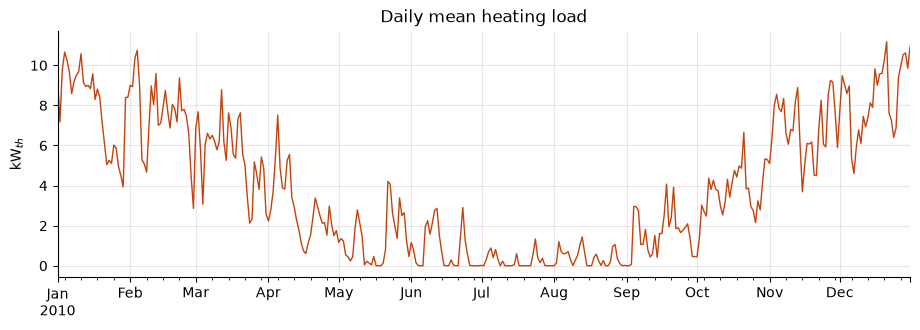

In [4]:
fig, ax = plt.subplots()
heat["Heating Load"].resample("D").mean().plot(ax=ax, lw=1.0, color="#c1440e")
ax.set_ylabel("kW$_{th}$")
ax.set_xlabel("")
ax.set_title("Daily mean heating load")
plt.show()

The specific demand of ~197 kWh/m²/a matches the IWU/TABULA reference for this archetype, which is
the external validation anchor of the model. It also survived two rewrites unchanged — the
component refactor and the migration to oemof-solph — and is pinned against the pre-migration
implementation by the golden fixtures in `test/data/golden/`.

<a id="2"></a>
## 2. Thermal mass as flexibility

Now the same building, but the heat is bought at a price that spikes every evening. Nothing about
the building changes — only the price signal. Because $T_{air}$ is a free variable inside the
comfort band, the optimizer can pre-heat and ride through the expensive hours on the building's
thermal mass.

To see this we build the system explicitly rather than through `Building.getHeatLoad()`.

In [5]:
WEEK = 168                                  # a winter week
cfg = dict(bdg.cfg)
cfg["weather"] = cfg["weather"].iloc[:WEEK]
for key in ["Q_ig", "occ_nothome", "occ_sleeping", "elecLoad"]:
    value = cfg[key]
    cfg[key] = value[:WEEK] if isinstance(value, np.ndarray) else value.iloc[:WEEK]

index = cfg["weather"].index
peak_hours = (index.hour >= 17) & (index.hour < 21)
cfg["heatPrice"] = np.where(peak_hours, 1.50, 0.05)


def run(comfort_ub):
    '''Solve the winter week with a given comfort ceiling.'''
    local = dict(cfg)
    local["comfortT_ub"] = comfort_ub
    spec = SystemSpec()
    spec.add_bus("heat", carrier="heat")
    spec.add_bus("cool", carrier="cool")
    spec.add_component("heat_supply", "source", bus="heat", price="@heatPrice")
    spec.add_component("cool_supply", "source", bus="cool", price=0.02)
    spec.add_component("zone", "zone5r1c", heat_bus="heat", cool_bus="cool")
    es, nodes = build_system(spec, local)
    model, _ = solve(es)
    return model, node_results(model, nodes, index=index)["zone"]["timeseries"]


flex_model, flexible = run(comfort_ub=26.0)          # band 20-26 degC
rigid_model, rigid = run(comfort_ub=20.0)            # band collapsed -> no flexibility

share = flexible["Heating Load"].values[peak_hours].sum() / flexible["Heating Load"].sum()
print("heat bought during the price spike: {:.1%} (spike is 17% of all hours)".format(share))
print("cost flexible : {:7.2f} EUR".format(objective_value(flex_model)))
print("cost rigid    : {:7.2f} EUR".format(objective_value(rigid_model)))
print("saving        : {:7.1%}".format(
    1 - objective_value(flex_model) / objective_value(rigid_model)))

heat bought during the price spike: 7.4% (spike is 17% of all hours)
cost flexible :  288.49 EUR
cost rigid    :  472.21 EUR
saving        :   38.9%


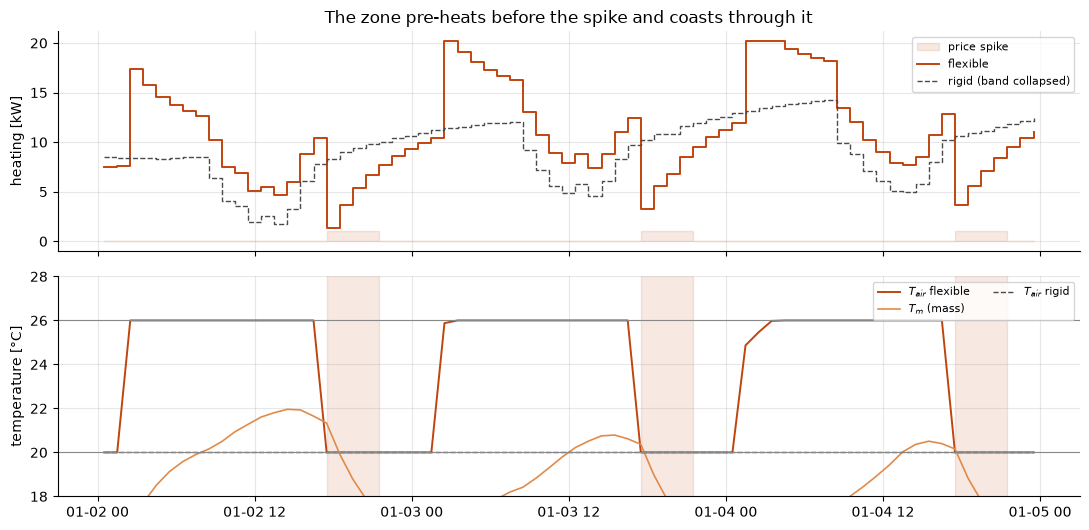

In [6]:
window = slice(24, 96)                       # three days
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 5.4), sharex=True)

ax1.fill_between(index[window], 0, np.where(peak_hours, 1, 0)[window],
                 color="#c1440e", alpha=0.12, step="post", label="price spike")
ax1.step(index[window], flexible["Heating Load"].values[window], where="post",
         color="#c1440e", lw=1.4, label="flexible")
ax1.step(index[window], rigid["Heating Load"].values[window], where="post",
         color="#4a4a4a", lw=1.0, ls="--", label="rigid (band collapsed)")
ax1.set_ylabel("heating [kW]")
ax1.legend(loc="upper right", fontsize=8)
ax1.set_title("The zone pre-heats before the spike and coasts through it")

ax2.fill_between(index[window], 0, np.where(peak_hours, 30, 0)[window],
                 color="#c1440e", alpha=0.12, step="post")
ax2.plot(index[window], flexible["T_air"].values[window], color="#c1440e",
         lw=1.4, label="$T_{air}$ flexible")
ax2.plot(index[window], flexible["T_m"].values[window], color="#e08b4a",
         lw=1.2, label="$T_m$ (mass)")
ax2.plot(index[window], rigid["T_air"].values[window], color="#4a4a4a",
         lw=1.0, ls="--", label="$T_{air}$ rigid")
ax2.axhline(20.0, color="#888", lw=0.8)
ax2.axhline(26.0, color="#888", lw=0.8)
ax2.set_ylim(18, 28)
ax2.set_ylabel("temperature [°C]")
ax2.legend(loc="upper right", fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

That is the whole argument for keeping the zone inside the optimization. The comfort band is the
storage capacity, the thermal mass is the storage medium, and both are dispatched by the same
solver that dispatches the battery in section 4. A model that reduced the building to a fixed heat
demand series could not produce the red curve.

<a id="3"></a>
## 3. The building block kit

A **`SystemSpec`** describes topology plus scalar parameters. A **preset** is a function returning
a spec — so presets are just named specs, and there is exactly one build path.

Time series never live in the spec: `"@key"` references are resolved against the building
configuration at build time. That is what keeps a spec small enough to store, diff and vary across
thousands of buildings.

In [7]:
spec = presets.heat_load_only()
print(json.dumps(spec.to_dict(), indent=2, sort_keys=True))

{
  "buses": {
    "cool": {
      "carrier": "cool"
    },
    "heat": {
      "carrier": "heat"
    }
  },
  "components": {
    "cool_supply": {
      "bus": "cool",
      "price": 0.02,
      "type": "source"
    },
    "heat_supply": {
      "bus": "heat",
      "price": 0.08,
      "type": "source"
    },
    "thermalzone": {
      "cool_bus": "cool",
      "heat_bus": "heat",
      "type": "zone5r1c"
    }
  }
}


In [8]:
# a spec is plain data, so it round-trips and can be edited before building
restored = SystemSpec.from_json(spec.to_json())
print("round trip identical:", restored.to_dict() == spec.to_dict())

custom = presets.hp_pv_battery(pv_kwp=8.0, battery_kwh=10.0)
custom.add_component("wallbox", "demand", bus="elec", profile=0.0)
print("components:", sorted(custom.components))

round trip identical: True
components: ['battery', 'cool_supply', 'demand', 'grid', 'hp', 'pv', 'thermalzone', 'wallbox']


### Adding a component

Every kit component except the thermal zone maps onto a stock solph object, so adding a technology
is *one factory function*. Here is a gas-fired CHP — the complete change, no constraints and no
solver knowledge:

In [9]:
from oemof import solph

from tsib.optimization.registry import _bus, _capacity, factory


@factory("chp")
def _chp(name, params, buses, cfg, n_steps, step_size_h):
    '''Gas-fired CHP: one fuel input, electricity and heat output.'''
    fuel = _bus(buses, params, "bus_fuel", name)
    elec = _bus(buses, params, "bus_elec", name)
    heat = _bus(buses, params, "bus_heat", name)
    capacity = _capacity(params, n_steps * step_size_h, params.pop("wacc", 0.0))
    return [
        solph.components.Converter(
            label=name,
            inputs={fuel: solph.Flow(nominal_capacity=capacity)},
            outputs={elec: solph.Flow(), heat: solph.Flow()},
            conversion_factors={
                elec: params.pop("electrical_efficiency", 0.35),
                heat: params.pop("thermal_efficiency", 0.50),
            },
        )
    ]


print("registered:", "chp" in tsib.optimization.COMPONENT_FACTORIES)

registered: True


The kit as it stands:

| spec `type` | solph object |
|---|---|
| `demand` | `Sink` with a fixed flow |
| `source` | `Source` with `variable_costs` |
| `grid` | `Source` **+** `Sink` (solph prices directed edges) |
| `meter` | `Converter` between two buses — the §14a sub-metering primitive |
| `pv` | `Source` with `maximum=yield` and optional `Investment` |
| `heat_pump` | `Converter` with `1/COP` conversion factors |
| `battery`, `thermal_storage` | `GenericStorage` |
| `zone5r1c` | **`ThermalZone5R1C`** — the one custom component |

<a id="4"></a>
## 4. A whole building

Heat pump, PV, battery and heat buffer on a time-varying tariff. PV and battery capacities are
**investment decisions**; the heat pump and buffer are fixed. Everything is solved at once, so the
building's thermal mass, the buffer and the battery compete for the same price signal.

In [10]:
DAYS = 14
n = DAYS * 24
sub = dict(bdg.cfg)
sub["weather"] = sub["weather"].iloc[:n]
for key in ["Q_ig", "occ_nothome", "occ_sleeping", "elecLoad"]:
    value = sub[key]
    sub[key] = value[:n] if isinstance(value, np.ndarray) else value.iloc[:n]

idx = sub["weather"].index
sub["cop"] = tsib.simHeatpump(sub["weather"]["T"], T_hot=45.0).values
sub["elecPrice"] = np.where((idx.hour >= 17) & (idx.hour < 21), 0.45, 0.12)
sub["pv_yield"] = np.clip(np.sin((idx.hour - 6) / 12 * np.pi), 0, None) * 0.6

whole = presets.hp_pv_battery(
    hp_kw=12.0,
    buffer_kwh=25.0,
    export_price=0.08,
    pv_kwp={"capex_per_unit": 1100.0, "lifetime": 25.0, "max_capacity": 15.0},
    battery_kwh={"capex_per_unit": 350.0, "lifetime": 15.0, "max_capacity": 20.0},
)

es, nodes = build_system(whole, sub)
model, _ = solve(es)
res = node_results(model, nodes, index=idx)

print("PV capacity      : {:6.2f} kWp   (investment decision)".format(res["pv"]["capacity"]))
print("battery capacity : {:6.2f} kWh   (investment decision)".format(res["battery"]["capacity"]))
print("total cost       : {:6.2f} EUR   over {} days".format(objective_value(model), DAYS))

PV capacity      :  15.00 kWp   (investment decision)
battery capacity :   5.06 kWh   (investment decision)
total cost       : 100.78 EUR   over 14 days


In [11]:
zone_ts = res["thermalzone"]["timeseries"]
imported = res["grid"]["out_elec"]
peak = (idx.hour >= 17) & (idx.hour < 21)

print("zone heat demand    : {:8.2f} kWh".format(zone_ts["Heating Load"].sum()))
print("heat pump output    : {:8.2f} kWh".format(res["hp"]["out_heat"].sum()))
print("heat pump input     : {:8.2f} kWh".format(res["hp"]["in_elec"].sum()))
print("seasonal perf. factor: {:7.2f}".format(
    res["hp"]["out_heat"].sum() / res["hp"]["in_elec"].sum()))
print("PV generation       : {:8.2f} kWh".format(res["pv"]["out_elec"].sum()))
print("grid import         : {:8.2f} kWh".format(imported.sum()))
print("... of which during the evening price peak: {:.1%}".format(
    imported[peak].sum() / imported.sum()))

zone heat demand    :  3205.97 kWh
heat pump output    :  3239.97 kWh
heat pump input     :  1075.26 kWh
seasonal perf. factor:    3.01
PV generation       :   957.07 kWh
grid import         :   546.05 kWh
... of which during the evening price peak: 1.0%


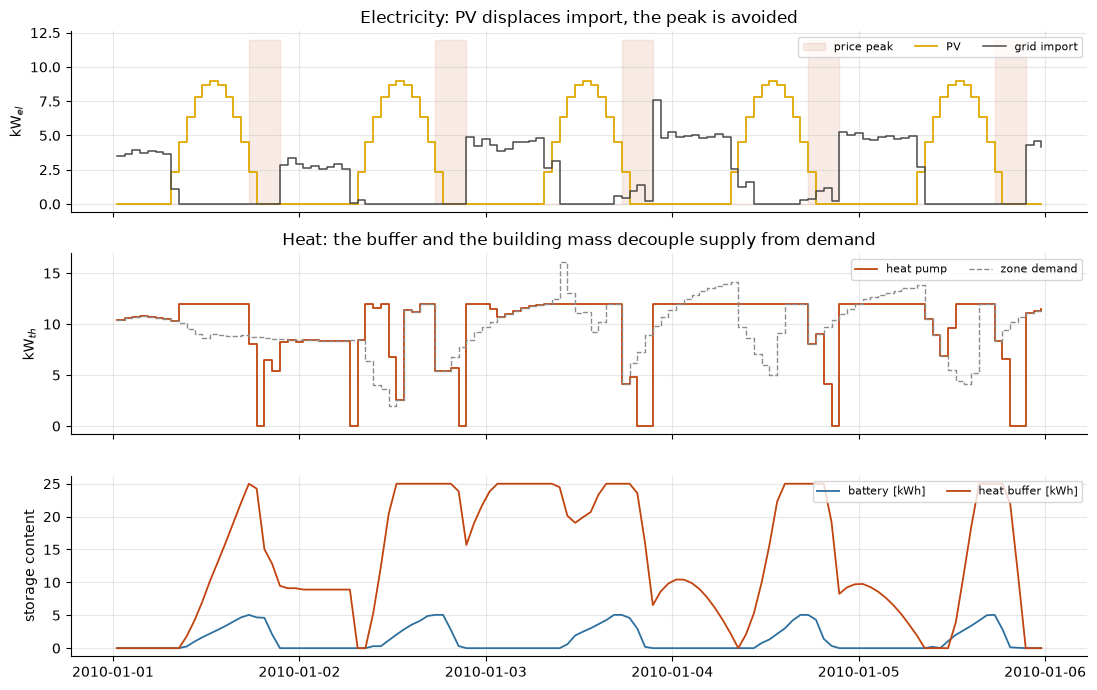

In [12]:
w = slice(0, 120)                            # five days
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(11, 7), sharex=True)

ax1.fill_between(idx[w], 0, np.where(peak, 1, 0)[w] * 12, color="#c1440e",
                 alpha=0.10, step="post", label="price peak")
ax1.step(idx[w], res["pv"]["out_elec"].values[w], where="post", color="#e0a800",
         lw=1.3, label="PV")
ax1.step(idx[w], imported.values[w], where="post", color="#4a4a4a", lw=1.1,
         label="grid import")
ax1.set_ylabel("kW$_{el}$")
ax1.legend(loc="upper right", fontsize=8, ncol=3)
ax1.set_title("Electricity: PV displaces import, the peak is avoided")

ax2.step(idx[w], res["hp"]["out_heat"].values[w], where="post", color="#c1440e",
         lw=1.3, label="heat pump")
ax2.step(idx[w], zone_ts["Heating Load"].values[w], where="post", color="#8c8c8c",
         lw=1.0, ls="--", label="zone demand")
ax2.set_ylabel("kW$_{th}$")
ax2.legend(loc="upper right", fontsize=8, ncol=2)
ax2.set_title("Heat: the buffer and the building mass decouple supply from demand")

ax3.plot(idx[w], res["battery"]["storage_content"].values[:len(idx)][w],
         color="#2e6f9e", lw=1.3, label="battery [kWh]")
ax3.plot(idx[w], res["buffer"]["storage_content"].values[:len(idx)][w],
         color="#c1440e", lw=1.3, label="heat buffer [kWh]")
ax3.set_ylabel("storage content")
ax3.legend(loc="upper right", fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

## What to read next

- **`docs/energysystem.md`** — the kit, the 5R1C formulation, a tutorial on adding a component,
  and the gotchas (two of which will bite you: a custom solph block **must** set
  `CONSTRAINT_GROUP = True`, and `EnergySystem` **must** be built with
  `infer_last_interval=True`).
- **`docs/model-deviations.md`** — four known deviations of the 5R1C zone from its source papers,
  all deliberately unfixed because they are load-bearing for the validated numbers. Read it before
  changing any equation.
- **Not available:** envelope/control refurbishment optimization was not migrated;
  `refurbishment=True` raises `NotImplementedError`.